<a href="https://colab.research.google.com/github/morojuindu4321/cspt_training2026/blob/main/data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_excel('/content/CineMetrics_Dataset.xlsx')
df.head()

,Movie_ID,Title,Genre,Release_Year,Duration_Min,Language,Country,Streaming_Platform,Budget_Million_USD,Revenue_Million_USD,IMDB_Rating,Votes_Thousands,Critic_Score,Director_Experience_Years
0,1,The Crimson Odyssey,Animation,2013,NaN,French,France,HBO Max,33.8,43.9,3.6,315.9,46.0,7.0
1,2,The Sacred Echo,Documentary,2014,88.0,Hindi,India,Prime Video,58.4,183.8,6.6,79.9,NaN,13.0
2,3,The Rising Illusion,Action,1995,105.0,Spanish,Mexico,HBO Max,12.8,13.8,6.8,71.9,32.0,30.0
3,4,The Crimson Awakening,Sci-Fi,2003,107.0,German,Germany,Netflix,11.4,27.8,8.0,74.6,81.0,33.0
4,5,The Last Legacy,Sci-Fi,2020,82.0,Hindi,India,Netflix,37.1,13.1,NaN,26.1,47.0,15.0


In [ ]:
df.shape

(300, 14)

In [ ]:
df.describe()

,Movie_ID,Release_Year,Duration_Min,Budget_Million_USD,Revenue_Million_USD,IMDB_Rating,Votes_Thousands,Critic_Score,Director_Experience_Years
count,300.000000,300.000000,285.000000,264.000000,273.000000,282.000000,285.000000,279.000000,288.000000
mean,150.500000,2008.680000,112.564912,32.051515,83.763736,6.465957,89.589123,59.390681,19.805556
std,86.746758,8.854695,21.138048,34.471101,107.025831,1.339428,78.999020,15.403963,11.729695
min,1.000000,1995.000000,70.000000,2.100000,0.000000,3.200000,5.000000,25.000000,0.000000
25%,75.750000,2001.000000,98.000000,12.800000,22.600000,5.600000,26.500000,48.000000,10.750000
50%,150.500000,2009.000000,112.000000,22.100000,51.900000,6.450000,69.600000,59.000000,20.000000
75%,225.250000,2016.250000,127.000000,38.450000,109.900000,7.400000,128.200000,70.000000,30.000000
max,300.000000,2024.000000,166.000000,300.000000,906.000000,9.700000,413.800000,100.000000,40.000000


In [ ]:
df.isnull().sum()

,0
Movie_ID,0
Title,0
Genre,12
Release_Year,0
Duration_Min,15
Language,9
Country,0
Streaming_Platform,9
Budget_Million_USD,36
Revenue_Million_USD,27


In [ ]:
numeric_cols = ['Duration_Min', 'Budget_Million_USD', 'Revenue_Million_USD',
                'IMDB_Rating', 'Votes_Thousands', 'Critic_Score',
                'Director_Experience_Years']

In [ ]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

In [ ]:
df[numeric_cols].isnull().sum()

,0
Duration_Min,0
Budget_Million_USD,0
Revenue_Million_USD,0
IMDB_Rating,0
Votes_Thousands,0
Critic_Score,0
Director_Experience_Years,0


In [ ]:
df.isnull().sum()

,0
Movie_ID,0
Title,0
Genre,12
Release_Year,0
Duration_Min,0
Language,9
Country,0
Streaming_Platform,9
Budget_Million_USD,0
Revenue_Million_USD,0


In [ ]:
before_rows = df.shape[0]
before_rows

300

In [ ]:
df = df.dropna()

In [ ]:
after_rows = df.shape[0]
print('Rows before:', before_rows)
print('Rows after: ', after_rows)
print('Dropped:    ', before_rows - after_rows)

Rows before: 300
Rows after:  271
Dropped:     29


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scale_cols = ['Duration_Min', 'Budget_Million_USD', 'Revenue_Million_USD',
              'IMDB_Rating', 'Votes_Thousands', 'Critic_Score',
              'Director_Experience_Years']

In [ ]:
scaler = MinMaxScaler()
df_scaled = df.copy()

In [ ]:
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

In [ ]:
df_scaled[scale_cols].describe().loc[['min', 'max']]

,Duration_Min,Budget_Million_USD,Revenue_Million_USD,IMDB_Rating,Votes_Thousands,Critic_Score,Director_Experience_Years
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

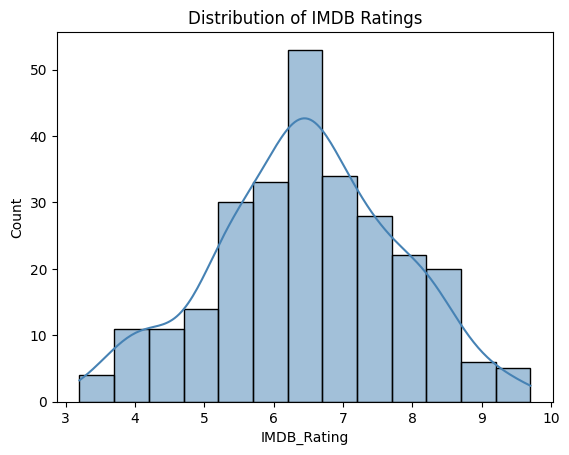

In [ ]:
sns.histplot(df['IMDB_Rating'], kde=True, color='steelblue')
plt.title('Distribution of IMDB Ratings')
plt.show()

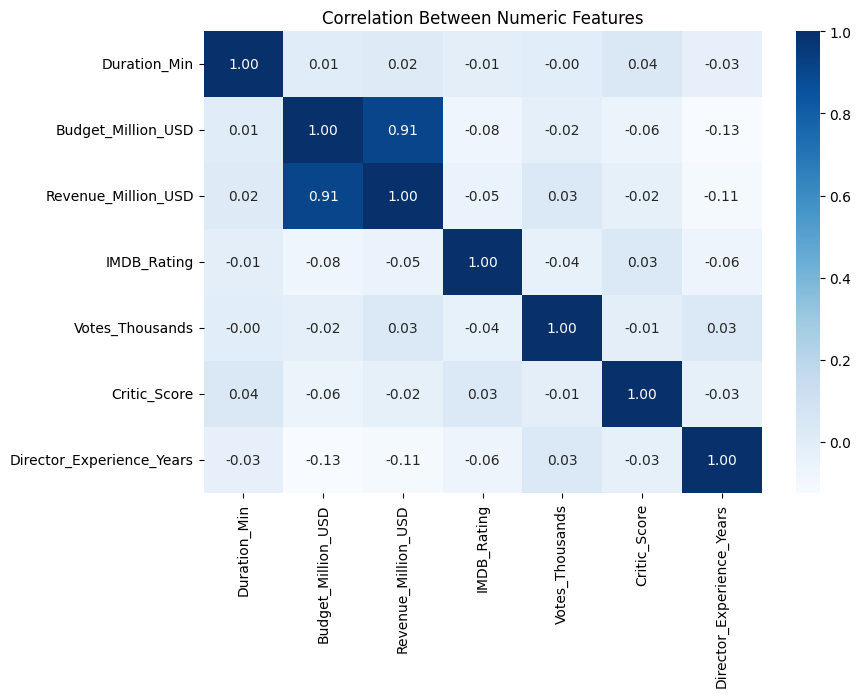

In [ ]:
plt.figure(figsize=(9, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Movie_ID                   300 non-null    int64  
 1   Title                      300 non-null    object 
 2   Genre                      288 non-null    object 
 3   Release_Year               300 non-null    int64  
 4   Duration_Min               285 non-null    float64
 5   Language                   291 non-null    object 
 6   Country                    300 non-null    object 
 7   Streaming_Platform         291 non-null    object 
 8   Budget_Million_USD         264 non-null    float64
 9   Revenue_Million_USD        273 non-null    float64
 10  IMDB_Rating                282 non-null    float64
 11  Votes_Thousands            285 non-null    float64
 12  Critic_Score               279 non-null    float64
 13  Director_Experience_Years  288 non-null    float64

In [ ]:
df1=df.fillna(df['Duration_Min'].mean())
df1

,Movie_ID,Title,Genre,Release_Year,Duration_Min,Language,Country,Streaming_Platform,Budget_Million_USD,Revenue_Million_USD,IMDB_Rating,Votes_Thousands,Critic_Score,Director_Experience_Years
0,1,The Crimson Odyssey,Animation,2013,112.564912,French,France,HBO Max,33.8,43.9,3.600000,315.9,46.000000,7.0
1,2,The Sacred Echo,Documentary,2014,88.000000,Hindi,India,Prime Video,58.4,183.8,6.600000,79.9,112.564912,13.0
2,3,The Rising Illusion,Action,1995,105.000000,Spanish,Mexico,HBO Max,12.8,13.8,6.800000,71.9,32.000000,30.0
3,4,The Crimson Awakening,Sci-Fi,2003,107.000000,German,Germany,Netflix,11.4,27.8,8.000000,74.6,81.000000,33.0
4,5,The Last Legacy,Sci-Fi,2020,82.000000,Hindi,India,Netflix,37.1,13.1,112.564912,26.1,47.000000,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,The Fading Mirage,Romance,2021,141.000000,French,France,HBO Max,66.0,173.3,5.000000,72.4,44.000000,30.0
296,297,The Sacred Journey,Fantasy,2014,110.000000,Spanish,Spain,HBO Max,43.2,52.3,3.900000,252.4,53.000000,32.0
297,298,The Burning Rebellion,Documentary,2006,158.000000,Korean,South Korea,HBO Max,114.3,165.6,8.100000,126.7,112.564912,8.0
298,299,The Fading Descent,Comedy,1999,114.000000,Japanese,Japan,HBO Max,188.8,661.6,5.300000,132.7,41.000000,25.0


In [ ]:
df2=df1.fillna(df['Budget_Million_USD'].mode())
df2

,Movie_ID,Title,Genre,Release_Year,Duration_Min,Language,Country,Streaming_Platform,Budget_Million_USD,Revenue_Million_USD,IMDB_Rating,Votes_Thousands,Critic_Score,Director_Experience_Years
0,1,The Crimson Odyssey,Animation,2013,112.564912,French,France,HBO Max,33.8,43.9,3.600000,315.9,46.000000,7.0
1,2,The Sacred Echo,Documentary,2014,88.000000,Hindi,India,Prime Video,58.4,183.8,6.600000,79.9,112.564912,13.0
2,3,The Rising Illusion,Action,1995,105.000000,Spanish,Mexico,HBO Max,12.8,13.8,6.800000,71.9,32.000000,30.0
3,4,The Crimson Awakening,Sci-Fi,2003,107.000000,German,Germany,Netflix,11.4,27.8,8.000000,74.6,81.000000,33.0
4,5,The Last Legacy,Sci-Fi,2020,82.000000,Hindi,India,Netflix,37.1,13.1,112.564912,26.1,47.000000,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,The Fading Mirage,Romance,2021,141.000000,French,France,HBO Max,66.0,173.3,5.000000,72.4,44.000000,30.0
296,297,The Sacred Journey,Fantasy,2014,110.000000,Spanish,Spain,HBO Max,43.2,52.3,3.900000,252.4,53.000000,32.0
297,298,The Burning Rebellion,Documentary,2006,158.000000,Korean,South Korea,HBO Max,114.3,165.6,8.100000,126.7,112.564912,8.0
298,299,The Fading Descent,Comedy,1999,114.000000,Japanese,Japan,HBO Max,188.8,661.6,5.300000,132.7,41.000000,25.0


In [ ]:
df3=df2.fillna(df['Revenue_Million_USD'].median())
df3

,Movie_ID,Title,Genre,Release_Year,Duration_Min,Language,Country,Streaming_Platform,Budget_Million_USD,Revenue_Million_USD,IMDB_Rating,Votes_Thousands,Critic_Score,Director_Experience_Years
0,1,The Crimson Odyssey,Animation,2013,112.564912,French,France,HBO Max,33.8,43.9,3.600000,315.9,46.000000,7.0
1,2,The Sacred Echo,Documentary,2014,88.000000,Hindi,India,Prime Video,58.4,183.8,6.600000,79.9,112.564912,13.0
2,3,The Rising Illusion,Action,1995,105.000000,Spanish,Mexico,HBO Max,12.8,13.8,6.800000,71.9,32.000000,30.0
3,4,The Crimson Awakening,Sci-Fi,2003,107.000000,German,Germany,Netflix,11.4,27.8,8.000000,74.6,81.000000,33.0
4,5,The Last Legacy,Sci-Fi,2020,82.000000,Hindi,India,Netflix,37.1,13.1,112.564912,26.1,47.000000,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,The Fading Mirage,Romance,2021,141.000000,French,France,HBO Max,66.0,173.3,5.000000,72.4,44.000000,30.0
296,297,The Sacred Journey,Fantasy,2014,110.000000,Spanish,Spain,HBO Max,43.2,52.3,3.900000,252.4,53.000000,32.0
297,298,The Burning Rebellion,Documentary,2006,158.000000,Korean,South Korea,HBO Max,114.3,165.6,8.100000,126.7,112.564912,8.0
298,299,The Fading Descent,Comedy,1999,114.000000,Japanese,Japan,HBO Max,188.8,661.6,5.300000,132.7,41.000000,25.0


In [ ]:
df4=df3.fillna(df['IMDB_Rating'].median())
df4

,Movie_ID,Title,Genre,Release_Year,Duration_Min,Language,Country,Streaming_Platform,Budget_Million_USD,Revenue_Million_USD,IMDB_Rating,Votes_Thousands,Critic_Score,Director_Experience_Years
0,1,The Crimson Odyssey,Animation,2013,112.564912,French,France,HBO Max,33.8,43.9,3.600000,315.9,46.000000,7.0
1,2,The Sacred Echo,Documentary,2014,88.000000,Hindi,India,Prime Video,58.4,183.8,6.600000,79.9,112.564912,13.0
2,3,The Rising Illusion,Action,1995,105.000000,Spanish,Mexico,HBO Max,12.8,13.8,6.800000,71.9,32.000000,30.0
3,4,The Crimson Awakening,Sci-Fi,2003,107.000000,German,Germany,Netflix,11.4,27.8,8.000000,74.6,81.000000,33.0
4,5,The Last Legacy,Sci-Fi,2020,82.000000,Hindi,India,Netflix,37.1,13.1,112.564912,26.1,47.000000,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,The Fading Mirage,Romance,2021,141.000000,French,France,HBO Max,66.0,173.3,5.000000,72.4,44.000000,30.0
296,297,The Sacred Journey,Fantasy,2014,110.000000,Spanish,Spain,HBO Max,43.2,52.3,3.900000,252.4,53.000000,32.0
297,298,The Burning Rebellion,Documentary,2006,158.000000,Korean,South Korea,HBO Max,114.3,165.6,8.100000,126.7,112.564912,8.0
298,299,The Fading Descent,Comedy,1999,114.000000,Japanese,Japan,HBO Max,188.8,661.6,5.300000,132.7,41.000000,25.0


In [ ]:
df5=df4.fillna(df['Votes_Thousands'].mean())
df5

,Movie_ID,Title,Genre,Release_Year,Duration_Min,Language,Country,Streaming_Platform,Budget_Million_USD,Revenue_Million_USD,IMDB_Rating,Votes_Thousands,Critic_Score,Director_Experience_Years
0,1,The Crimson Odyssey,Animation,2013,112.564912,French,France,HBO Max,33.8,43.9,3.600000,315.9,46.000000,7.0
1,2,The Sacred Echo,Documentary,2014,88.000000,Hindi,India,Prime Video,58.4,183.8,6.600000,79.9,112.564912,13.0
2,3,The Rising Illusion,Action,1995,105.000000,Spanish,Mexico,HBO Max,12.8,13.8,6.800000,71.9,32.000000,30.0
3,4,The Crimson Awakening,Sci-Fi,2003,107.000000,German,Germany,Netflix,11.4,27.8,8.000000,74.6,81.000000,33.0
4,5,The Last Legacy,Sci-Fi,2020,82.000000,Hindi,India,Netflix,37.1,13.1,112.564912,26.1,47.000000,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,The Fading Mirage,Romance,2021,141.000000,French,France,HBO Max,66.0,173.3,5.000000,72.4,44.000000,30.0
296,297,The Sacred Journey,Fantasy,2014,110.000000,Spanish,Spain,HBO Max,43.2,52.3,3.900000,252.4,53.000000,32.0
297,298,The Burning Rebellion,Documentary,2006,158.000000,Korean,South Korea,HBO Max,114.3,165.6,8.100000,126.7,112.564912,8.0
298,299,The Fading Descent,Comedy,1999,114.000000,Japanese,Japan,HBO Max,188.8,661.6,5.300000,132.7,41.000000,25.0


In [ ]:
df6=df5.fillna(df['Critic_Score'].mean())
df6

,Movie_ID,Title,Genre,Release_Year,Duration_Min,Language,Country,Streaming_Platform,Budget_Million_USD,Revenue_Million_USD,IMDB_Rating,Votes_Thousands,Critic_Score,Director_Experience_Years
0,1,The Crimson Odyssey,Animation,2013,112.564912,French,France,HBO Max,33.8,43.9,3.600000,315.9,46.000000,7.0
1,2,The Sacred Echo,Documentary,2014,88.000000,Hindi,India,Prime Video,58.4,183.8,6.600000,79.9,112.564912,13.0
2,3,The Rising Illusion,Action,1995,105.000000,Spanish,Mexico,HBO Max,12.8,13.8,6.800000,71.9,32.000000,30.0
3,4,The Crimson Awakening,Sci-Fi,2003,107.000000,German,Germany,Netflix,11.4,27.8,8.000000,74.6,81.000000,33.0
4,5,The Last Legacy,Sci-Fi,2020,82.000000,Hindi,India,Netflix,37.1,13.1,112.564912,26.1,47.000000,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,The Fading Mirage,Romance,2021,141.000000,French,France,HBO Max,66.0,173.3,5.000000,72.4,44.000000,30.0
296,297,The Sacred Journey,Fantasy,2014,110.000000,Spanish,Spain,HBO Max,43.2,52.3,3.900000,252.4,53.000000,32.0
297,298,The Burning Rebellion,Documentary,2006,158.000000,Korean,South Korea,HBO Max,114.3,165.6,8.100000,126.7,112.564912,8.0
298,299,The Fading Descent,Comedy,1999,114.000000,Japanese,Japan,HBO Max,188.8,661.6,5.300000,132.7,41.000000,25.0


In [ ]:
df6=df5.fillna(df['Director_Experience_Years'].mean())
df6

,Movie_ID,Title,Genre,Release_Year,Duration_Min,Language,Country,Streaming_Platform,Budget_Million_USD,Revenue_Million_USD,IMDB_Rating,Votes_Thousands,Critic_Score,Director_Experience_Years
0,1,The Crimson Odyssey,Animation,2013,112.564912,French,France,HBO Max,33.8,43.9,3.600000,315.9,46.000000,7.0
1,2,The Sacred Echo,Documentary,2014,88.000000,Hindi,India,Prime Video,58.4,183.8,6.600000,79.9,112.564912,13.0
2,3,The Rising Illusion,Action,1995,105.000000,Spanish,Mexico,HBO Max,12.8,13.8,6.800000,71.9,32.000000,30.0
3,4,The Crimson Awakening,Sci-Fi,2003,107.000000,German,Germany,Netflix,11.4,27.8,8.000000,74.6,81.000000,33.0
4,5,The Last Legacy,Sci-Fi,2020,82.000000,Hindi,India,Netflix,37.1,13.1,112.564912,26.1,47.000000,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,296,The Fading Mirage,Romance,2021,141.000000,French,France,HBO Max,66.0,173.3,5.000000,72.4,44.000000,30.0
296,297,The Sacred Journey,Fantasy,2014,110.000000,Spanish,Spain,HBO Max,43.2,52.3,3.900000,252.4,53.000000,32.0
297,298,The Burning Rebellion,Documentary,2006,158.000000,Korean,South Korea,HBO Max,114.3,165.6,8.100000,126.7,112.564912,8.0
298,299,The Fading Descent,Comedy,1999,114.000000,Japanese,Japan,HBO Max,188.8,661.6,5.300000,132.7,41.000000,25.0


In [ ]:
df6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Movie_ID                   300 non-null    int64  
 1   Title                      300 non-null    object 
 2   Genre                      300 non-null    object 
 3   Release_Year               300 non-null    int64  
 4   Duration_Min               300 non-null    float64
 5   Language                   300 non-null    object 
 6   Country                    300 non-null    object 
 7   Streaming_Platform         300 non-null    object 
 8   Budget_Million_USD         300 non-null    float64
 9   Revenue_Million_USD        300 non-null    float64
 10  IMDB_Rating                300 non-null    float64
 11  Votes_Thousands            300 non-null    float64
 12  Critic_Score               300 non-null    float64
 13  Director_Experience_Years  300 non-null    float64